## Dimensionality Reduction with PCA
This notebook performs Principal Component Analysis (PCA) on the preprocessed fMRI data prepared in the previous notebook. The goal is to reduce the dimensionality of the neural response data while retaining as much variance as possible, enabling more efficient downstream classifier operations.

#### Objectives
- Load the processed training and test datasets generated in `01_data.ipynb`.
- Apply PCA to the training data to identify principal components.
- Project both training and test data onto the principal component space.
- Analyze the explained variance and visualize the results.
- Save the PCA-transformed datasets for use in further modeling or analysis.

#### Outputs
- PCA model and variance ratios
- Transformed train and test datasets
- Visualizations of variance and principal component projections

## 1. Import Libraries & Load Data

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Load data
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
output_dir = os.path.abspath(os.path.join(notebook_dir, '..', 'outputs', 'processed'))

X_train = np.load(os.path.join(output_dir, 'X_train.npy'))
X_test = np.load(os.path.join(output_dir, 'X_test.npy'))
y_train = np.load(os.path.join(output_dir, 'y_train.npy'))
y_test = np.load(os.path.join(output_dir, 'y_test.npy'))

## 2. PCA
Here, I first tried adapting the method from lectures on PCA of sorting eigenvectors and projecting data onto top PC elements. However, this led to insufficient RAM due to the larget number of voxels (which creates a huge covariance matrix). Therefore, I will proceed with SVD instead.

In [2]:
# Standardize data
X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0) + 1e-10  # Avoid division by zero
X_train_std[X_train_std == 0] = 1.0  # Avoid division by zero

X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

X_train_centered = X_train_scaled
X_test_centered = X_test_scaled

# SVD-based PCA
U, S, Vt = np.linalg.svd(X_train_centered, full_matrices=False)
PCs = Vt.T[:, :100]  # Keep top 100 PCs
explained_variance = (S ** 2) / (X_train_centered.shape[0] - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()

# Project data onto PCs
X_train_pca = X_train_centered @ PCs
X_test_pca = X_test_centered @ PCs

# Save projected data for future use
np.save(os.path.join(output_dir, 'X_train_pca.npy'), X_train_pca)
np.save(os.path.join(output_dir, 'X_test_pca.npy'), X_test_pca)
np.save(os.path.join(output_dir, "X_train_mean.npy"), X_train_mean)
np.save(os.path.join(output_dir, "X_train_std.npy"), X_train_std)
np.save(os.path.join(output_dir, "PCs.npy"), PCs)

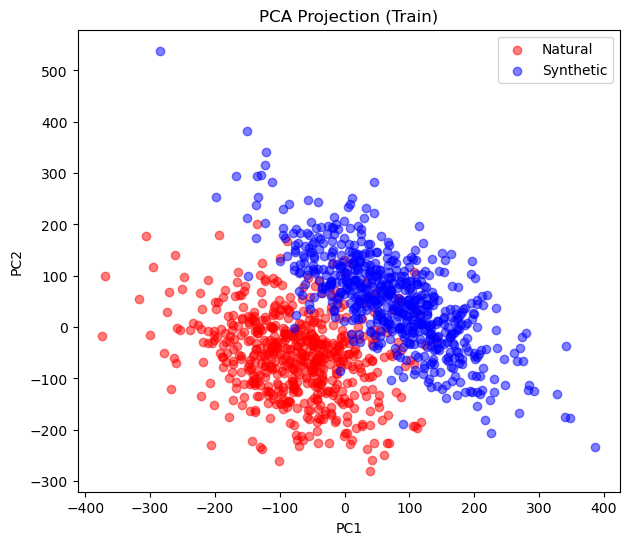

In [21]:
# Visualize the first two PCs with labels
colors = ['red' if y == 0 else 'blue' for y in y_train]
labels = ['Natural' if y == 0 else 'Synthetic' for y in y_train]

plt.figure(figsize=(7, 6))
for group, color, label in zip([0, 1], ['red', 'blue'], ['Natural', 'Synthetic']):
    idx = (y_train == group)
    plt.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], c=color, label=label, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (Train)')
plt.legend()
plt.show()

#### Findings
Natural and synthetic visual stimuli evoke separable low-dimensional fMRI response patterns.

## 3. Condition-specific PCA Visualizations
I'd also like to visualize condition-specific variance between natural and synthetic stimuli, as well as comparing dimensionality for each condition.

Number of components to reach variance threshold:
Group	80%	90%
Nat	284	400
Syn	261	388


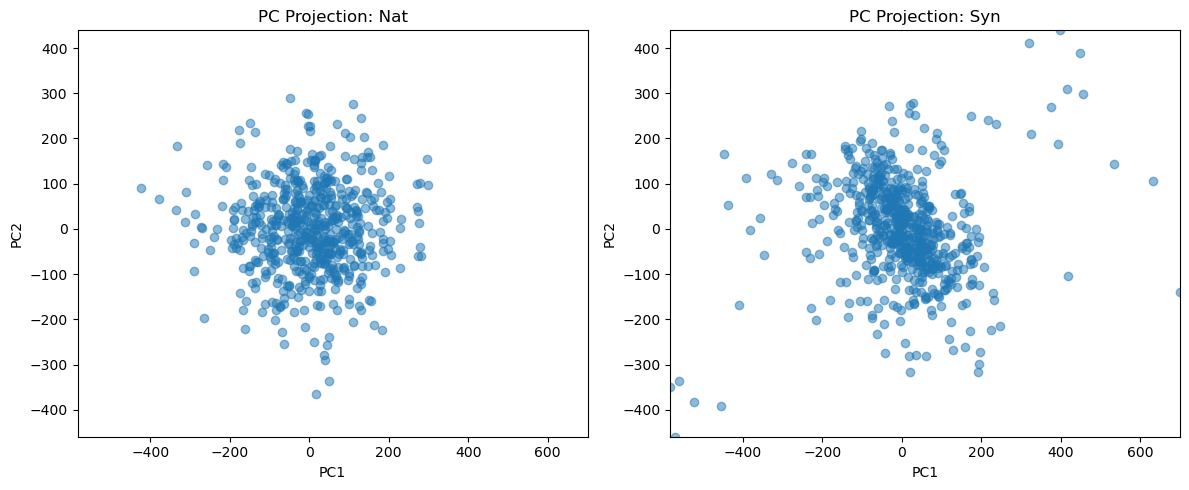

In [23]:
groups = [0, 1]
group_names = ['Nat', 'Syn']

# Number of components to reach 80%/90% variance per group
thresholds = [0.8, 0.9]
print('Number of components to reach variance threshold:')
print('Group\t80%\t90%')

# Top 2 PCs per group
plt.figure(figsize=(12, 5))
proj_data = []
for i, (group, name) in enumerate(zip(groups, group_names)):
    X_group = X_train[y_train == group]
    mean = np.mean(X_group, axis=0)
    std = np.std(X_group, axis=0, ddof=0)
    std[std == 0] = 1
    X_group_scaled = (X_group - mean) / std
    U, S, Vt = np.linalg.svd(X_group_scaled, full_matrices=False)

    # Calculate explained variance and find number of components for thresholds
    explained_variance = (S ** 2) / (X_group_scaled.shape[0] - 1)
    explained_variance_ratio = explained_variance / explained_variance.sum()
    cumvar = np.cumsum(explained_variance_ratio)
    n_80 = np.searchsorted(cumvar, 0.8) + 1
    n_90 = np.searchsorted(cumvar, 0.9) + 1
    print(f'{name}\t{n_80}\t{n_90}')

    PCs = Vt.T[:, :2]
    X_proj = X_group_scaled @ PCs
    proj_data.append(X_proj)

# Find global axis limits
all_proj = np.vstack(proj_data)
xmin, xmax = all_proj[:, 0].min(), all_proj[:, 0].max()
ymin, ymax = all_proj[:, 1].min(), all_proj[:, 1].max()

for i, (X_proj, name) in enumerate(zip(proj_data, group_names)):
    plt.subplot(1, 2, i+1)
    plt.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'PC Projection: {name}')
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
plt.tight_layout()
plt.show()


#### Findings
The number of principal components required to explain 80% and 90% of the variance is similar for both natural and synthetic conditions (Nat: 284/400, Syn: 261/388). This suggests that the overall dimensionality of neural responses is comparable across conditions, and reduced dimensionality alone is not sufficient to distinguish between natural and synthetic stimuli.

However, the synthetic condition exhibits more sporadic and outlying points in the PC space, indicating greater trial-to-trial variability. This may reflect less consistent neural encoding or greater heterogeneity in response to artificial images.

## 4. Further Investigation with FA
Given the experimental setup, subject latent factors such as attention, fatigue, and other physiological noise may contribute to the observed data distribution. FA can help reveal whether these factors are significant contributors to the observed variance in PCA.

In [ ]:
def FA(X, n_factors):
    """
    Factor Analysis implementation using SVD.
    - X: (n_samples, n_features) standardized data matrix
    - n_factors: number of latent factors

    Returns:
    - L: (n_features, n_factors) factor loadings matrix
    - psi: (n_features,) unique variances
    - factors: (n_samples, n_factors) factor scores
    """

    X_centered = X - np.mean(X, axis=0)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    L = Vt[:n_factors].T * S[:n_factors] / np.sqrt(X_centered.shape[0] - 1)
    psi = np.var(X_centered, axis=0) - np.sum(L ** 2, axis=1)
    psi = np.maximum(psi, 1e-10)
    inv_psi = 1 / psi

    # Element-wise multiplication for memory efficiency
    XL = (X_centered * inv_psi) @ L # (n_samples, n_factors)
    LL = L.T @ (L * inv_psi[:, None]) # (n_factors, n_factors)
    factors = XL @ np.linalg.inv(np.eye(n_factors) + LL)

    return L, psi, factors

In [30]:
n_factors = 5
L_nat, psi_nat, factors_nat = FA(X_train[y_train == 0], n_factors)
L_syn, psi_syn, factors_syn = FA(X_train[y_train == 1], n_factors)

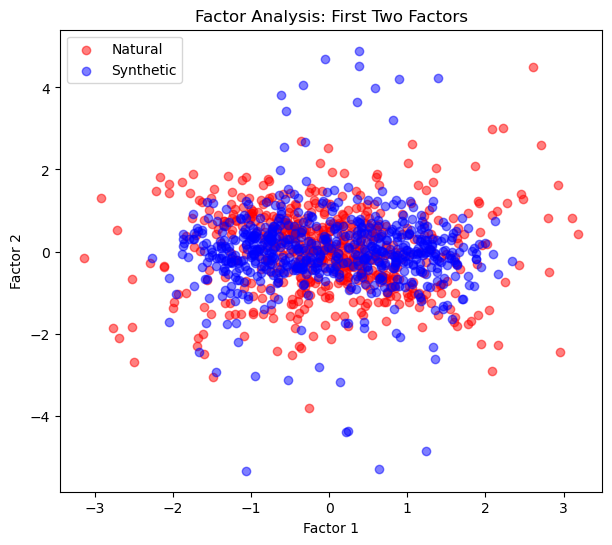

In [31]:
plt.figure(figsize=(7, 6))
plt.scatter(factors_nat[:, 0], factors_nat[:, 1], color='red', alpha=0.5, label='Natural')
plt.scatter(factors_syn[:, 0], factors_syn[:, 1], color='blue', alpha=0.5, label='Synthetic')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title('Factor Analysis: First Two Factors')
plt.legend()
plt.show()

#### Findings
The first two latent factors from FA did not provide strong separation between natural and synthetic conditions. Combined with the PCA results, this suggests that the main sources of shared variance are present throughout both conditions, and that latent structures do not contribute much to the pattern observed from PCA. Shared variation is likely due to global noise or other higher level neural processes that is inaccessible with fMRI data.

I will still proceed with PCA-processed data for classifiers in the next step.